============================== -> poem_res <- ==============================
{'topic': '布偶狗', 'content_type': '诗', 'poem': '《咏布偶狗》\n彩线织成憨态身，眸如点漆卧芳茵。\n不惊不吠常缄口，却伴孤窗十载春。\n\n赏析：这首作品以布偶狗为题，通过“彩线织成”展现其工艺之美，“眸如点漆”绘其神态之灵。后两句以“不惊不吠”衬其静默特性，尾句“伴孤窗十载春”则赋予物象以人情温度，于寂寥中见守候深情，语言凝练而意蕴绵长。', 'ci_poem': '《鹧鸪天·布偶狗》\n絮毛团子卧雕栊，憨眸如漆窥帘栊。\n爪扑流萤千线络，尾摇星子一灯融。\n衔月影，逗檐风，睫间残梦总朦胧。\n忽然闻得铃铛响，跃入春云第几重？\n\n注：我的创作思路是通过古典意象重构现代玩具的生命感。以“絮毛团子”喻布偶质感，“流萤千线”暗合针线工艺，尾摇星灯则赋予静态玩物灵动诗意。下阕“衔月影”三句，将宠物狗与布偶特性糅合，最终“跃入春云”的虚写，在玩具与生灵的边界上完成审美跳跃，呼应陆游“纸上得来终觉浅”的辩证哲思。'}
============================== -> joke_res <- ==============================
{'topic': '布偶狗', 'content_type': '笑话', 'ci_poem': '《鹧鸪天·布偶狗》\n彩线金瞳布偶身，棉团玉骨掌中温。\n朝陪稚子庭前戏，暮伴慈亲榻侧陈。\n蓬尾扫，软绒伸。憨姿镇日守虚门。\n无端最是垂髫笑，拽尾牵鬃唤作真。\n\n注：我的创作思路是通过古典词牌咏物寄情，以“彩线金瞳”“棉团玉骨”勾勒布偶狗的精巧形态。下阕“垂髫笑”与“唤作真”形成虚实对照，既保留玩具的物性特征，又赋予其陪伴童真的情感温度。结句以儿童视角收束，将布偶狗视为有生命的玩伴，暗含对赤子之心的礼赞。', 'joke': '“布偶狗”这个词本身就挺有画面感的，给您编一个：\n\n---\n\n我朋友小李养了只“布偶狗”。\n\n不是那种毛茸茸的玩偶，是真的狗，但脾气像布偶一样软。\n\n他训练了它一个月，想教会它“握手”。结果狗学是学会了，但只会在它自己想被撸的时候，才抬起爪子。\n\n昨天小李气呼

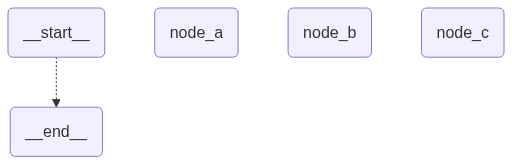

In [1]:
from collections.abc import Sequence
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    ci_poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的词")]).content

    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    return ["node_b", "node_c"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(
    START,
    my_route
)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "布偶狗", "content_type": "诗"})
joke_res = graph.invoke({"topic": "布偶狗", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)